*© 2026 Paul Fergus*

# Lab 11 — Explainability: Grad-CAM and saliency maps

**Module:** 7144COMP — Deep Learning Concepts and Techniques
**Week:** 11
**Estimated time:** 210 minutes

---

## Requirements

This lab reuses the **trained checkpoints from Lab 3** (`checkpoints/mnist_cnn.pt`) and **Lab 5** (`checkpoints/cell_cnn.pt`). If either is missing, open that lab and run it through its "save the model" cell first. A GPU speeds things up but isn't required — everything here runs comfortably on CPU too.

## Learning outcomes

By the end of this lab you should be able to:

1. Explain why post-hoc explainability matters for trust and debugging, and describe the "Clever Hans" pattern — a model that performs well by learning a spurious shortcut rather than the genuine task.
2. Compute a **saliency map** from first principles — the gradient of a class score with respect to the input pixels.
3. Implement **Grad-CAM** from first principles using forward and backward hooks on a convolutional layer, and explain what each step (pooled gradients, weighted combination, ReLU) contributes.
4. Compare a gradient-based explanation (Grad-CAM) against a model-agnostic, perturbation-based one (**occlusion sensitivity**), and state a concrete advantage and disadvantage of each.
5. Use these tools to audit a trained model for evidence that it is — or isn't — looking at the right thing, including running a **controlled test** for a spurious shortcut.

## Prerequisites

- **Lab 3** — the trained MNIST CNN (`SmallCNN`) and its checkpoint.
- **Lab 5** — the trained malaria-cell CNN (`CellCNN`) and its checkpoint. If you attempted Lab 5 Exercise 3 Option C, you've already had a preview of today — we now build the same idea properly, from first principles, and go further.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 5.
- Lecture 11: *Explainability in deep learning — saliency, Grad-CAM, and the limits of post-hoc explanation.*

## The thread from last week

Lab 10 gave us pixel-precise masks — we now know exactly *where* a model's output refers to. But across every lab since Lab 3 we've trained networks that make confident decisions — *this digit is a 7*, *this cell is parasitized*, *this pixel-region is an elephant* — without ever asking **why**. A model can be right for the wrong reason. The canonical cautionary tale: a widely-cited image classifier that appeared to distinguish wolves from huskies, but had actually learned to detect **snow in the background**, because every wolf photo in its training set happened to have snow and every husky photo didn't (Ribeiro et al., 2016). It scored beautifully on its test set — which shared the same accidental correlation — and would have failed silently the first time it saw a husky in snow, or a wolf without it.

This pattern has a name — the **"Clever Hans" effect**, after a horse once believed to do arithmetic, who was in fact reading tiny involuntary cues from his trainer's posture. Hans wasn't doing maths; he was doing something else that happened to produce the right answer *in the conditions he was tested under*. The uncomfortable question for every model we've trained this module: **is it possible any of them are Clever Hans predictors?** Today we get tools to actually look.

## Useful references

- Simonyan, K., Vedaldi, A. and Zisserman, A. (2014). *Deep Inside Convolutional Networks: Visualising Image Classification Models and Saliency Maps.*
- Selvaraju, R.R. et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.*
- Zeiler, M.D. and Fergus, R. (2014). *Visualizing and Understanding Convolutional Networks* — the occlusion-sensitivity method.
- Ribeiro, M.T., Singh, S. and Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier* — the wolf/husky example, and the LIME method.
- Lapuschkin, S. et al. (2019). *Unmasking Clever Hans Predictors and Assessing What Machines Really Learn.*

---

## 1. Why explain a prediction?

Three reasons this isn't just academic curiosity:

- **Trust.** Before you deploy a model — especially in a domain like Lab 5's malaria screening — you want evidence it's using genuine signal, not an accident of how the dataset was built.
- **Debugging.** When a model fails in an unexpected way, an explanation tells you *what it was looking at* when it got things wrong, which is far more actionable than a bare accuracy number.
- **Catching shortcuts before deployment, not after.** Lab 8 taught us to catch a generalisation gap by testing on an independent, out-of-distribution set — an *outcome*-based check: does performance hold up on new data? Explainability is a *mechanism*-based check: does the model's evidence make sense, even on data it currently gets right? The two are complementary. A mechanism check can catch a shortcut cheaply, before you've gone to the trouble of building a whole new test set.

Lab 5's synthetic malaria dataset is a plausible place for a shortcut to hide. The parasitized and uninfected images were generated by the same synthetic pipeline — if that pipeline left *any* systematic difference beyond the dark parasite spot (a subtly different background tone, a compression artefact, anything correlated with the label but not causally related to malaria), a CNN would happily learn it, score extremely well in-distribution, and give you no warning. Today's tools are how you'd catch that.

## 2. Load the trained digit classifier from Lab 3

We recreate the exact `SmallCNN` architecture from Lab 3 and load its saved weights. If you see a `FileNotFoundError` below, open Lab 3 and run it through Section 6 (the `torch.save` cell) first.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

RNG_SEED = 7144
torch.manual_seed(RNG_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


class SmallCNN(nn.Module):
    """Identical to Lab 3's architecture — required to load its state_dict."""

    def __init__(self, n_classes: int = 10, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


MNIST_CKPT = Path("../lab03_cnn_mnist/checkpoints/mnist_cnn.pt")
if not MNIST_CKPT.is_file():
    raise FileNotFoundError(
        "No checkpoint found. Open Lab 3 and run it through Section 6 "
        "(the torch.save cell) first."
    )

digit_model = SmallCNN().to(DEVICE)
digit_model.load_state_dict(torch.load(MNIST_CKPT, map_location=DEVICE, weights_only=True))
digit_model.eval()
print(f"Loaded {MNIST_CKPT}")

MNIST_MEAN, MNIST_STD = 0.1307, 0.3081
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])
mnist_test = datasets.MNIST(root="data", train=False, download=True, transform=mnist_transform)
print(f"MNIST test set: {len(mnist_test)} images")

Device: cuda
Loaded ../lab03_cnn_mnist/checkpoints/mnist_cnn.pt


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.21MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 368kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.67MB/s]

MNIST test set: 10000 images


## 3. Saliency maps — the gradient of the prediction with respect to the input

The simplest possible explanation method (Simonyan et al., 2014): compute the gradient of the predicted class **score** with respect to every **input pixel**. A large gradient magnitude at a pixel means: *nudging this pixel would change the score a lot* — i.e. the model's decision is sensitive to it. Small gradient: the model barely notices that pixel.

This needs nothing but autograd, which you've been using since Lab 1 — the only new idea is that we differentiate with respect to the **input image** instead of the model's weights.

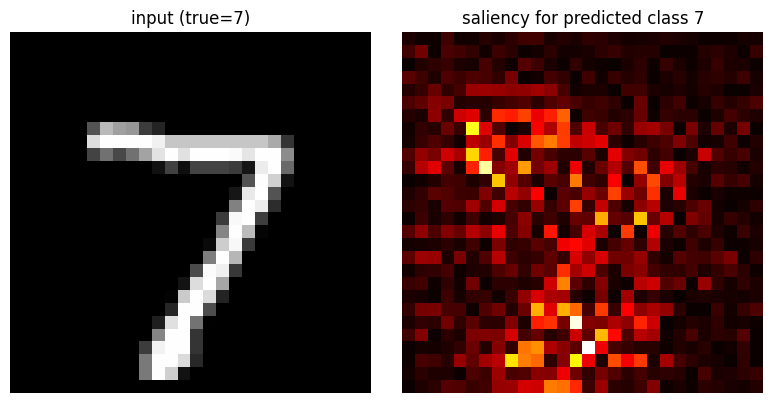

In [2]:
def compute_saliency(model, x: torch.Tensor, target_class: int) -> np.ndarray:
    """Vanilla gradient saliency map. x is a single image tensor (C, H, W), no batch dim."""
    model.eval()
    x = x.clone().unsqueeze(0).to(DEVICE)
    x.requires_grad_(True)

    logits = model(x)
    score = logits[0, target_class]

    model.zero_grad()
    if x.grad is not None:
        x.grad.zero_()
    score.backward()

    saliency = x.grad.detach().abs().squeeze().cpu().numpy()   # (C, H, W) or (H, W)
    if saliency.ndim == 3:
        saliency = saliency.max(axis=0)   # collapse channels: most-sensitive channel wins
    return saliency


# Try it on one correctly-classified test digit.
img, true_label = mnist_test[0]
with torch.no_grad():
    pred_label = digit_model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()

sal = compute_saliency(digit_model, img, pred_label)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
display_img = img.squeeze().numpy() * MNIST_STD + MNIST_MEAN
axes[0].imshow(display_img, cmap="gray"); axes[0].set_title(f"input (true={true_label})"); axes[0].axis("off")
axes[1].imshow(sal, cmap="hot"); axes[1].set_title(f"saliency for predicted class {pred_label}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 4. Grad-CAM from first principles

Saliency maps operate on raw pixels, which makes them noisy — individual pixels rarely carry semantic meaning on their own. **Grad-CAM** (Selvaraju et al., 2017) instead uses the activations of a **convolutional layer**, which have already learned to represent meaningful spatial patterns, and asks the same question at that level: which *regions* of the feature map most influence the class score?

The algorithm, in four steps:

1. **Forward pass**, capturing the activations `A` of a chosen convolutional layer (shape: channels × height × width).
2. **Backward pass** from the target class score, capturing the gradients `∂score/∂A` flowing into that same layer.
3. **Global-average-pool** the gradients over the spatial dimensions to get one importance weight `α_k` per channel `k` — "on average, how much does channel `k` matter for this class?"
4. Take the **weighted sum** of the activation maps using these `α_k` weights, then apply **ReLU** — keeping only the regions that *positively* support the class (a region that argues *against* the class isn't part of "why the model chose this class").

The result is a low-resolution heatmap the size of that layer's feature map, which we upsample back to the input image size for the final overlay.

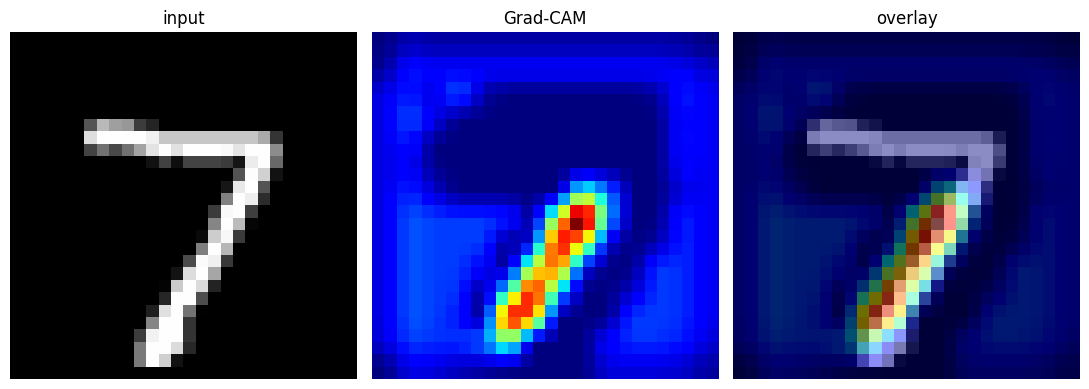

In [3]:
class GradCAM:
    """Grad-CAM for a single target layer. Register once, call repeatedly."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x: torch.Tensor, target_class: int) -> np.ndarray:
        """x is a single image tensor (C, H, W), no batch dim. Returns a (H, W) heatmap in [0, 1]."""
        self.model.eval()
        x = x.clone().unsqueeze(0).to(DEVICE)

        self.model.zero_grad()
        logits = self.model(x)
        score = logits[0, target_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)          # (1, C, 1, 1)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))  # (1, 1, h, w)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


# Target the last conv block before pooling — bn2 gives a 14x14 map, higher
# resolution than the 7x7 you'd get after the final MaxPool2d.
digit_gradcam = GradCAM(digit_model, digit_model.bn2)

cam = digit_gradcam(img, pred_label)
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(display_img, cmap="gray"); axes[0].set_title("input"); axes[0].axis("off")
axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
axes[2].imshow(display_img, cmap="gray")
axes[2].imshow(cam, cmap="jet", alpha=0.45)
axes[2].set_title("overlay"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## 5. Correct vs. incorrect — where does the model look?

Explanations are most informative in contrast. Find one digit the model gets right and one it gets wrong, and compare their saliency maps and Grad-CAMs side by side.

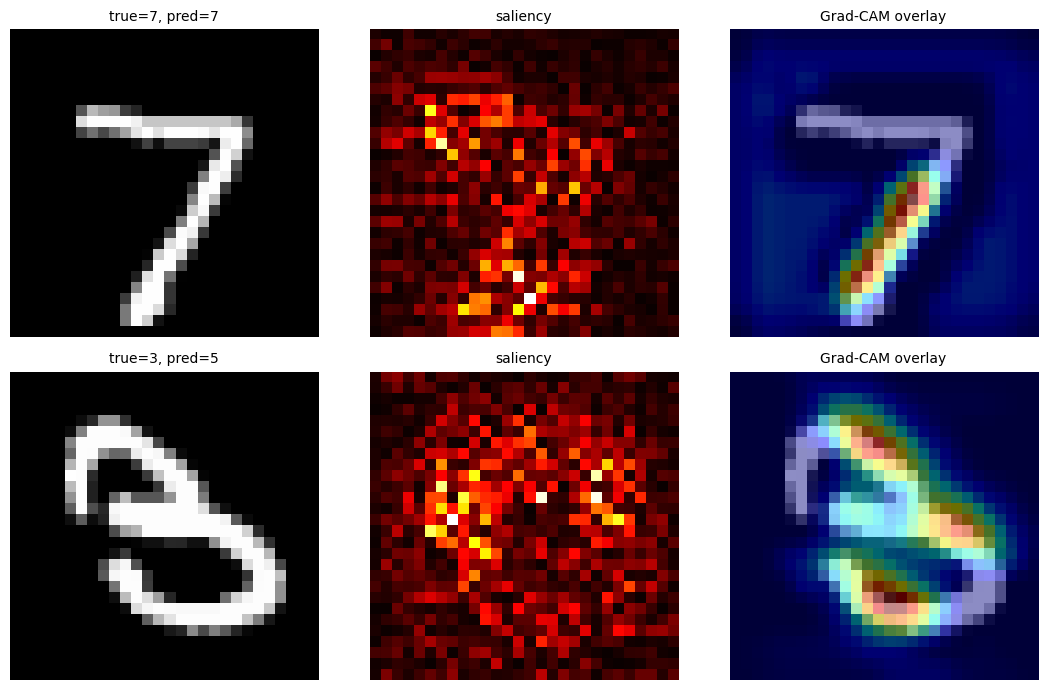

In [4]:
from torch.utils.data import DataLoader

test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False)
all_preds, all_labels, all_imgs = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = digit_model(xb.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(yb); all_imgs.append(xb)
all_preds = torch.cat(all_preds); all_labels = torch.cat(all_labels); all_imgs = torch.cat(all_imgs)

correct_idx = (all_preds == all_labels).nonzero().squeeze()[0].item()
wrong_idx_candidates = (all_preds != all_labels).nonzero().squeeze()
wrong_idx = wrong_idx_candidates[0].item() if wrong_idx_candidates.numel() > 0 else correct_idx

def explain_and_plot(idx, axes_row):
    x = all_imgs[idx]
    true_l = all_labels[idx].item()
    pred_l = all_preds[idx].item()
    disp = x.squeeze().numpy() * MNIST_STD + MNIST_MEAN
    sal = compute_saliency(digit_model, x, pred_l)
    cam = digit_gradcam(x, pred_l)

    axes_row[0].imshow(disp, cmap="gray")
    axes_row[0].set_title(f"true={true_l}, pred={pred_l}", fontsize=10)
    axes_row[1].imshow(sal, cmap="hot")
    axes_row[1].set_title("saliency", fontsize=10)
    axes_row[2].imshow(disp, cmap="gray")
    axes_row[2].imshow(cam, cmap="jet", alpha=0.45)
    axes_row[2].set_title("Grad-CAM overlay", fontsize=10)
    for ax in axes_row:
        ax.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
explain_and_plot(correct_idx, axes[0])
explain_and_plot(wrong_idx, axes[1])
axes[0, 0].set_ylabel("correct", fontsize=11)
axes[1, 0].set_ylabel("misclassified", fontsize=11)
plt.tight_layout(); plt.show()

**What to look for.** On the correct example, the heatmap should concentrate on the strokes that actually distinguish that digit — e.g. the closed loop of an 8, the crossbar of a 7. On the misclassified example, look at *which* strokes it focused on: does the highlighted region explain the confusion (e.g. attention on an ambiguous curve shared between the true digit and the wrongly-predicted one)? If so, the mistake is at least an "understandable" one — evidence the model is engaging with genuine digit structure, just drawing the wrong conclusion from ambiguous evidence, rather than being lost entirely.

## 6. The higher-stakes case — Lab 5's malaria classifier

MNIST is a safe place to learn the mechanics. Now apply the same tools somewhere the answer actually matters: is the malaria-cell classifier from Lab 5 looking at the parasite, or at something else?

In [5]:
from torchvision import datasets as tv_datasets
from PIL import Image

class CellCNN(nn.Module):
    """Identical to Lab 5's architecture — required to load its state_dict."""

    def __init__(self, n_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.flat_dim = 128 * 16 * 16
        self.fc1 = nn.Linear(self.flat_dim, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


CELL_CKPT = Path("../lab05_custom_image_data/checkpoints/cell_cnn.pt")
if not CELL_CKPT.is_file():
    raise FileNotFoundError(
        "No checkpoint found. Open Lab 5 and run it through Section 9 "
        "(the torch.save cell) first."
    )

cell_model = CellCNN().to(DEVICE)
cell_model.load_state_dict(torch.load(CELL_CKPT, map_location=DEVICE, weights_only=True))
cell_model.eval()
print(f"Loaded {CELL_CKPT}")

IMAGE_SIZE = 130
CELL_MEAN, CELL_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
cell_eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CELL_MEAN, CELL_STD),
])

CELL_DATA_DIR = Path("../lab05_custom_image_data/data/cell_images")
cell_test = tv_datasets.ImageFolder(root=CELL_DATA_DIR / "test", transform=cell_eval_transform)
class_names = cell_test.classes   # ['parasitized', 'uninfected']
print(f"Cell test set: {len(cell_test)} images, classes: {class_names}")

def un_normalise_cell(t: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(CELL_MEAN).view(3, 1, 1)
    std = torch.tensor(CELL_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

Loaded ../lab05_custom_image_data/checkpoints/cell_cnn.pt
Cell test set: 600 images, classes: ['parasitized', 'uninfected']


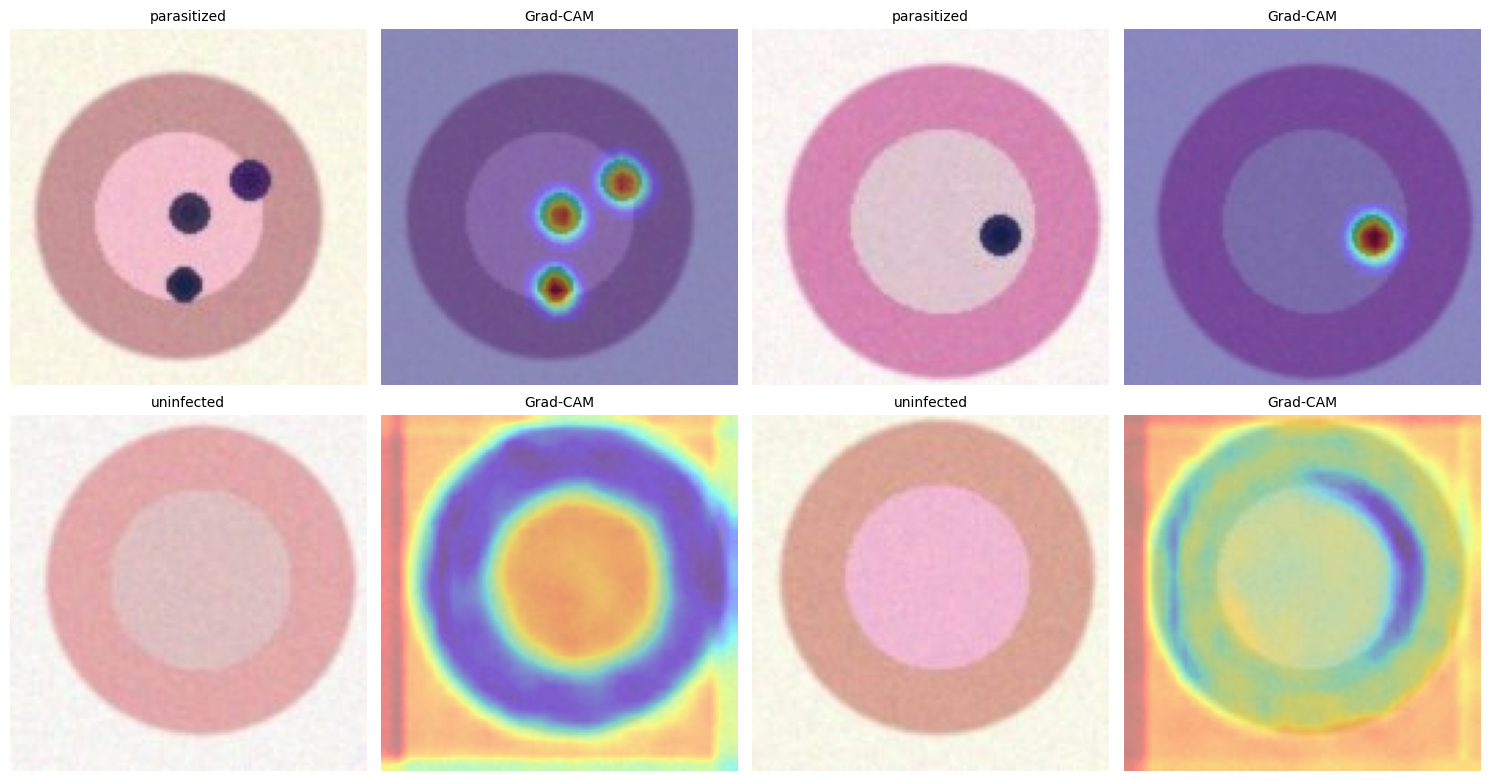

In [6]:
# Grad-CAM on the last conv block (bn3, 16x16 resolution).
cell_gradcam = GradCAM(cell_model, cell_model.bn3)

# Pick 2 correctly-classified parasitized and 2 correctly-classified uninfected images.
by_class = {0: [], 1: []}   # 0=parasitized, 1=uninfected (alphabetical, per ImageFolder)
for i in range(len(cell_test)):
    _, label = cell_test.samples[i]
    if len(by_class[label]) < 6:
        by_class[label].append(i)
    if len(by_class[0]) >= 6 and len(by_class[1]) >= 6:
        break

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for row, cls in enumerate((0, 1)):
    shown = 0
    for idx in by_class[cls]:
        if shown >= 2:
            break
        x, true_l = cell_test[idx]
        with torch.no_grad():
            pred_l = cell_model(x.unsqueeze(0).to(DEVICE)).argmax(1).item()
        if pred_l != true_l:
            continue   # only show correctly-classified examples here
        disp = un_normalise_cell(x)
        cam = cell_gradcam(x, pred_l)
        c = shown * 2
        axes[row, c].imshow(disp); axes[row, c].axis("off")
        axes[row, c].set_title(f"{class_names[true_l]}", fontsize=10)
        axes[row, c+1].imshow(disp); axes[row, c+1].imshow(cam, cmap="jet", alpha=0.45)
        axes[row, c+1].axis("off"); axes[row, c+1].set_title("Grad-CAM", fontsize=10)
        shown += 1
plt.tight_layout(); plt.show()

**The trust check.** For the **parasitized** row: does the hot region sit on the dark parasite spot(s) you can see by eye, or somewhere else entirely (the cell edge, the image border, empty background)? For the **uninfected** row: since there's no parasite to find, where does the model look instead — is there a consistent "this is what healthy tissue looks like" region, or does the heatmap look arbitrary? If parasitized predictions consistently light up on the actual dark spot, that's good evidence the model learned the real task. If it doesn't, you've just caught a possible Clever Hans predictor — exactly the scenario the introduction warned about, and exactly why we check *before* trusting the model's accuracy number alone.

## 7. Occlusion sensitivity — a model-agnostic alternative

Both methods so far are **gradient-based**: they need access to the model's internals and require it to be differentiable. **Occlusion sensitivity** (Zeiler & Fergus, 2014) needs neither. It treats the model as a black box and asks a much more direct, causal question: *if I hide this region, how much does the model's confidence actually drop?*

The method: slide a grey patch across the image; at each position, re-run the (occluded) image through the model and record how much the target class's probability falls compared to the unoccluded baseline. A big drop means that region was doing real work; no drop means the model didn't need it.

This is slower — one forward pass **per patch position**, versus Grad-CAM's single forward+backward pass — but it directly measures the model's actual behaviour rather than relying on the gradient as a proxy.

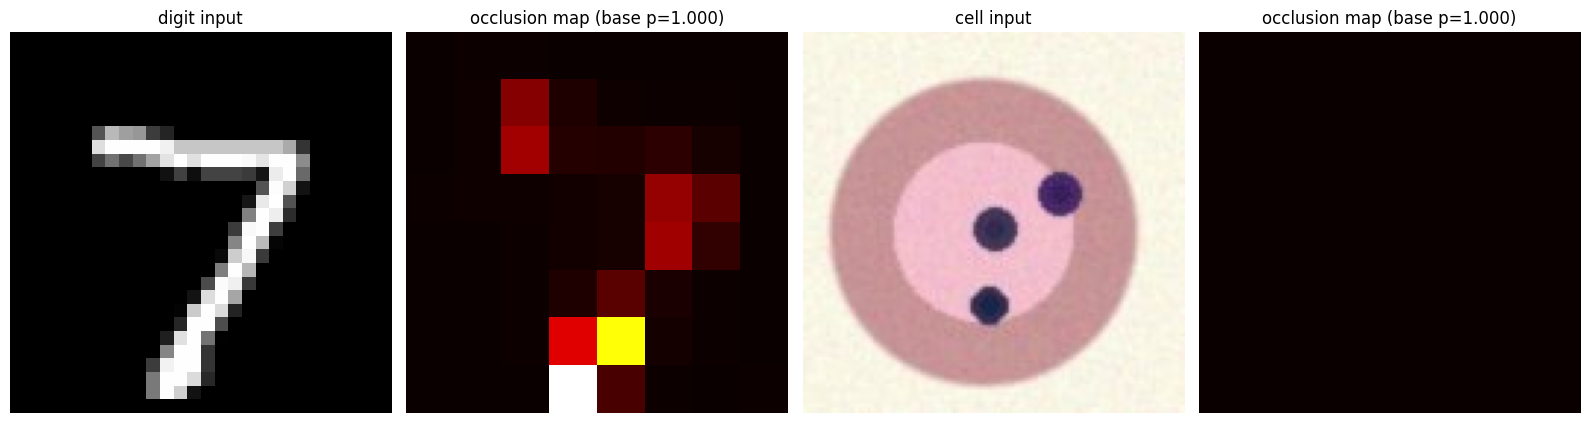

In [7]:
def occlusion_sensitivity(model, x: torch.Tensor, target_class: int,
                           patch_size: int = 16, stride: int = 8, baseline_value: float = 0.0) -> tuple:
    """Slide an occluding patch over x, measuring the drop in target-class probability.
    x is a single image tensor (C, H, W). Returns (heatmap, base_probability).
    """
    model.eval()
    x = x.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        base_prob = F.softmax(model(x), dim=1)[0, target_class].item()

    _, C, H, W = x.shape
    n_rows = (H - patch_size) // stride + 1
    n_cols = (W - patch_size) // stride + 1
    heatmap = np.zeros((n_rows, n_cols))

    with torch.no_grad():
        for i, top in enumerate(range(0, H - patch_size + 1, stride)):
            for j, left in enumerate(range(0, W - patch_size + 1, stride)):
                occluded = x.clone()
                occluded[:, :, top:top + patch_size, left:left + patch_size] = baseline_value
                prob = F.softmax(model(occluded), dim=1)[0, target_class].item()
                heatmap[i, j] = base_prob - prob   # positive = occluding this region hurt confidence

    return heatmap, base_prob


# Compare on one MNIST digit and one malaria cell.
occ_digit, base_p_digit = occlusion_sensitivity(digit_model, img, pred_label, patch_size=6, stride=3)
sample_x, sample_true = cell_test[by_class[0][0]]
with torch.no_grad():
    sample_pred = cell_model(sample_x.unsqueeze(0).to(DEVICE)).argmax(1).item()
occ_cell, base_p_cell = occlusion_sensitivity(cell_model, sample_x, sample_pred, patch_size=20, stride=10)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
axes[0].imshow(display_img, cmap="gray"); axes[0].axis("off"); axes[0].set_title("digit input")
axes[1].imshow(occ_digit, cmap="hot"); axes[1].axis("off")
axes[1].set_title(f"occlusion map (base p={base_p_digit:.3f})")
axes[2].imshow(un_normalise_cell(sample_x)); axes[2].axis("off"); axes[2].set_title("cell input")
axes[3].imshow(occ_cell, cmap="hot"); axes[3].axis("off")
axes[3].set_title(f"occlusion map (base p={base_p_cell:.3f})")
plt.tight_layout(); plt.show()

**Reading the comparison.** Occlusion's heatmap is blocky (one value per patch position, not per pixel) and slow to compute, but it's a direct measurement, not an approximation — nothing about it depends on the gradient being well-behaved. Compare its hot region against Grad-CAM's from Sections 4/6 on a shared example if you have time: broad agreement is reassuring; a sharp disagreement is worth investigating (Exercise 2 asks you to do this properly).

---

## 8. Exercise 1 — six digits, six explanations

Pick **six** correctly-classified MNIST test digits, one from each of six different true classes of your choice. For each, compute and display both the saliency map and the Grad-CAM overlay (reuse `explain_and_plot` or write a similar loop).

For each of the six, judge in one sentence: does the highlighted region correspond to the stroke *you* would point to as a human to justify that digit's identity? Report how many of the six "make sense" to you, and describe your one clearest counter-example (a case where the highlighted region genuinely puzzled you).

In [ ]:
# Your code for Exercise 1 here.

*Your six judgements and the counter-example:*

## 9. Exercise 2 — do Grad-CAM and occlusion agree?

For **4 malaria cell images** (2 correctly-classified parasitized, 2 correctly-classified uninfected), compute **both** Grad-CAM and occlusion sensitivity, and display them side by side (4 rows × 3 columns: original, Grad-CAM, occlusion).

1. For each image, describe in one sentence whether the two methods agree on the important region.
2. Find (or construct, by trying a few images) at least one case where they clearly **disagree**. Offer a hypothesis for why — consider Grad-CAM's lower spatial resolution, possible gradient saturation in a confidently-correct prediction, or occlusion's blocky patch grid missing a small, precisely-located feature.

In [ ]:
# Your code for Exercise 2 here.

*Your agreement/disagreement findings and hypothesis:*

## 10. Exercise 3 — open-ended (pick one)

**Option A — Hunt for a shortcut.** Take 5 **uninfected** test images and digitally add a small dark dot in a **corner** of each — well away from where a real parasite would appear (e.g. `image[5:12, 5:12] = 0` on the tensor, before normalisation). Run the edited images through `cell_model`. Does the predicted probability of "parasitized" increase? Does Grad-CAM light up on your fake dot? Report your result and what it implies about how much you would trust this model in deployment — a model that reacts to *any* dark pixel anywhere is a much weaker finding than one that reacts specifically to plausible parasite locations.

**Option B — Grad-CAM at different depths.** Register a second `GradCAM` on an **early** layer (`bn1`) as well as the late layer (`bn2` for the digit model, or `bn3` for the cell model) and compare the two CAMs on the same image. Early layers tend to produce higher-resolution but less class-discriminative maps (they respond to generic edges/texture); late layers are coarser but more semantically tied to the class. Show both side by side on at least 3 images and write 3–5 sentences on the trade-off you observe.

**Option C — A Grad-CAM-based QA check.** For a sample of at least 10 correctly-classified **parasitized** cell images, build a simple automatic "does the model look at the right place?" check: threshold each image to roughly locate the dark parasite spot yourself (e.g. pixels below some darkness threshold, within the cell), then measure what fraction of Grad-CAM's "hot" pixels (above 70% of that image's max CAM value) fall inside that region versus outside it. Report the distribution of this fraction across your sample. Would this be a useful automated QA gate to run before deploying a retrained model? What would you set as a pass/fail threshold, and why?

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.

*Which option did you pick, and what did you find?*

---

## 11. Reflection questions

**Q1.** In your own words, explain what a saliency map tells you about a prediction, and state its main limitation.

**Q2.** Grad-CAM uses gradients flowing into a convolutional layer rather than the raw input pixels. What does this buy you compared to a vanilla input-pixel saliency map, and what does it cost?

**Q3.** Occlusion sensitivity never touches the model's gradients or internal layers. Describe one concrete situation where you could use occlusion but not Grad-CAM, and one concrete disadvantage of occlusion compared to Grad-CAM.

**Q4.** Referring back to Lab 8's discussion of the generalisation gap: explain why a "Clever Hans" model — one that has learned a spurious shortcut — can still score very well on an in-distribution test split. If explainability tools like today's didn't exist, what kind of test *would* catch it?

**Q5.** You are advising a hospital about deploying the malaria classifier from Lab 5. Based on what you saw in this lab's Grad-CAM/occlusion analysis (and Exercise 3, if you chose Option A), would you recommend deployment as-is, deployment with a mandatory human-in-the-loop check, or no deployment yet? Justify in 3–5 sentences using evidence you actually observed in this lab.

*Your answers:*

**A1.**

**A2.**

**A3.**

**A4.**

**A5.**

---

## What's next

Across this module you've gone from a perceptron implemented in raw numpy to training, segmenting, and now interrogating deep networks on real tasks — image classification, object detection, instance segmentation, and, today, the question of whether a model's stated reasons for a decision hold up to inspection. **Lab 12** picks up the first thread this leaves dangling directly: every CNN in this module shares an architectural assumption — locality, baked in from layer one — that a Vision Transformer deliberately does without. You'll build self-attention from first principles, then measure empirically what that trade-off actually costs (or buys) on a small dataset. Wherever the module — or your own work — takes the models after that (generative models, deployment at scale, foundation models bigger still than the ones in Lab 9 and Lab 10), the habits practised here transfer directly: **measure honestly (Lab 8), audit before you trust (today), and understand a tool before you deploy it.** That discipline outlasts any specific architecture.

Before leaving today, make sure:

- [ ] You implemented saliency maps and Grad-CAM from first principles and ran both on the digit classifier
- [ ] You ran Grad-CAM on the malaria classifier and formed a view on whether it looks at the parasite
- [ ] You implemented occlusion sensitivity and compared it against Grad-CAM
- [ ] You completed Exercises 1, 2, and 3
- [ ] You answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors**